<a href="https://colab.research.google.com/github/johanidler/notebooks/blob/main/micrograd_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://youtu.be/VMj-3S1tku0?t=3937

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x +5

In [ ]:
f(3.0)

20.0

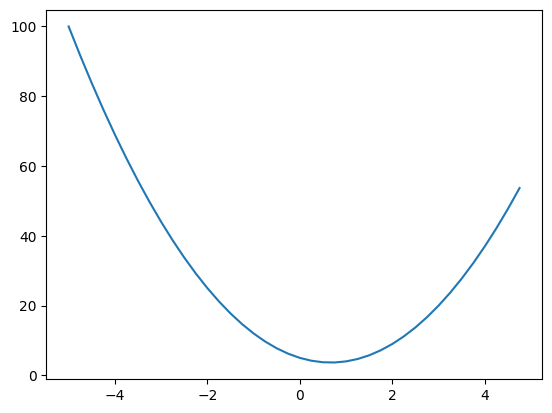

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys
plt.plot(xs, ys)

In [ ]:
h = 0.0001
x = -3.0
(f(x + h) - f(x)) / h

-21.999700000066014

In [ ]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
d

4.0

In [ ]:
d1 = a*b + c
b += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('derivative', (d2 - d1)/h)

d1 4.0
d2 4.0002
derivative 2.0000000000042206


In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label


  def __repr__(self):
    return f"Value of {self.label} is {self.data}"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), ('+'))

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), ('*'))

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
      self.grad = (1 - t**2) * out.grad

    out._backward = _backward

    return out

In [ ]:
#usage of lambda
test = lambda x: x + 5
p = 5

print(test(p))

10


In [ ]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b; e.label = 'e'

d = e + c; d.label = 'd'

f = Value(-2.0, label = 'f')

L = d*f; L.label='L'

print(L)


Value of L is -8.0


In [ ]:
# we are now going to run though this graph and trying to caluclate the derivative of each node in respect to L to see how changing this variable changes the size of L
# L stans for the loss fucntion

In [ ]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape='record'
        )

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)

            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [ ]:
# now calculate the derivate of L, d, f manually and bring them in using L.grad =

In [ ]:
h = 0.001

a2 = Value(2.0, label='a')
b2 = Value(-3.0, label='b')
c2 = Value(10.0, label='c')

e2 = a2*b2; e.label = 'e'

d2 = e2 + c2; d.label = 'd'

f2 = Value(-2.0, label = 'f')

L2 = d2*f2; L2.label='L2'

print(L2)

a3 = Value(2.0, label='a')
b3 = Value(-3.0, label='b')
c3 = Value(10.0, label='c')

a3.data = a3.data + h

e3 = a3*b3; e.label = 'e'

d3 = e3 + c3; d.label = 'd'

f3 = Value(-2.0, label = 'f')

L3 = d3*f3; L3.label='L3'
print(L3)

derivative = (L3.data - L2.data) / h
print(derivative)



Value of L2 is -8.0
Value of L3 is -7.994
6.000000000000227


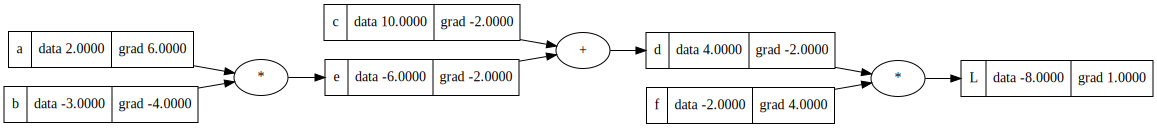

In [ ]:
L.grad = 1
d.grad = -2
f.grad = 4
e.grad = -2
c.grad = -2
b.grad = -4
a.grad = +6
draw_dot(L)

In [ ]:
## Backpropagation throuhg a neuron

In [ ]:
#implementing a neuron

# input
x1 = Value(2.0); x1.label='x1'
x2= Value(0.0); x2.label='x2'
# weights
w1 = Value(-3.0); w1.label='w1'
w2 = Value(1.0); w2.label='w2'
# bias
b = Value(6.8813735870195432); b.label='b'

# calculations
x1w1 = x1 * w1; x1w1.label = 'x1 * w1'
x2w2 = x2 * w2; x2w2.label = 'x2 * w2'
#sum of them
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'
print(o)


Value of o is 0.7071067811865476


In [ ]:
o.grad = 1.0
n.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
w1.grad = x1.data * 0.5
x1.grad = w1.data * 0.5
w2.grad = x2.data * 0.5
x2.grad = w2.data * 0.5

In [ ]:
o.grad = 1.0

In [ ]:
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

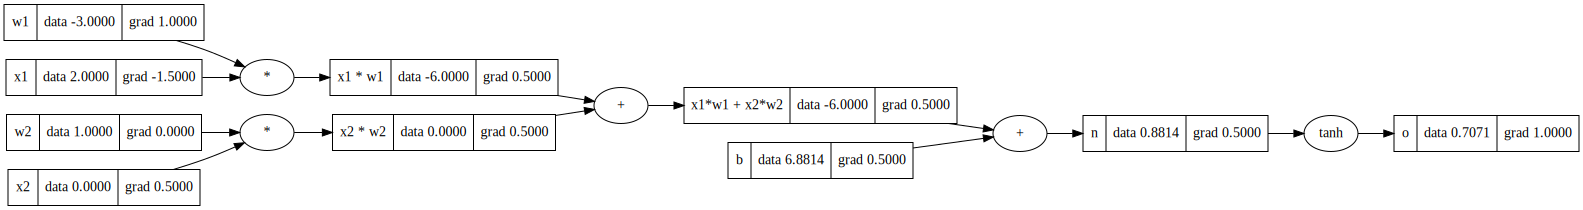

In [ ]:
draw_dot(o)